# ASTR Synthetic CMD — Revised Final Paper Figure Generator

Run this script from anywhere:

    python3 notebooks/2026/08-12_full-analysis/
        astr_synthetic_cmd_final_paper_figures_revised.py

`WORK_ROOT` is anchored to the script location, so the existing analysis
outputs and SPISEA cache are found correctly regardless of cwd.

This revision implements the requested plotting changes:

- The H-R panel is shown over its full cached temperature range.
- Isochrone age coding uses `coolwarm`.
- Isochrone curves are sorted by mass and broken at large discontinuities
  before plotting, preventing spurious long connector lines / crossovers.
- The diagram-space geometry figure shows the ACTUAL fixed measurement-bin
  geometry from `static_1myr_bin_definitions.csv`:
      * H-R: fixed 3000, 3100, ..., 3600 K edges.
      * CMDs: six equal-width fixed COLOR bins between the 1 Myr colors
        corresponding to 3000 K and 3600 K.
- Spread-vs-time and spread-vs-age-spread results are each generated as
  ONE all-diagram multipanel figure, not separate primary/secondary figures.
- The geometry/bin figure also overlays a representative interpolated cluster.
- Adds a representative F182M-F200W cluster over the isochrone grid.
- Adds a 2x3 time-evolution sequence for one cluster seed in
  F182M-F200W vs F200W, with the coolwarm isochrone grid in every panel.

Existing draft Figures 1--4, 6, and 7 are not regenerated here.
The new F182M-F200W time-evolution figure is intended to supersede the old
F162M-F182M age-evolution figure if preferred.

Main outputs:

  fig_analysis_space_isochrone_geometry.png
  fig_representative_cluster_f182m_f200w.png
  fig_cluster_time_evolution_f182m_f200w.png
  fig_ensemble_age_spread_vs_time.png
  fig_ensemble_spread_vs_time_all_spaces.png
  fig_ensemble_spread_vs_age_spread_all_spaces.png

Ensemble convention is exactly the prior analysis:
arithmetic mean across seeds, shaded/error extent = +/-1 sample SD (ddof=1).

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
# Locate the analysis directory whether this code is run as a normal .py
# script, an interactive notebook, or an nbconvert-executed notebook.
def find_work_root() -> Path:
    expected = "all_seeds_all_sigma_all_eff_spread_std_outputs"
    candidates = []

    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parent)

    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.append(cwd / "notebooks" / "2026" / "08-12_full-analysis")

    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "notebooks" / "2026" / "08-12_full-analysis")
        candidates.append(parent / "08-12_full-analysis")

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / expected).is_dir():
            print(f"Using WORK_ROOT: {candidate}")
            return candidate

    attempted = "\n".join(f"  {c}" for c in seen)
    raise FileNotFoundError(
        "Could not locate the 08-12_full-analysis directory containing "
        f"{expected}. Candidates checked:\n{attempted}"
    )


WORK_ROOT = find_work_root()

ANALYSIS_OUTPUT_DIR = (
    WORK_ROOT / "all_seeds_all_sigma_all_eff_spread_std_outputs"
)
ISO_CACHE_DIR = WORK_ROOT / "iso_cache"
FIGURE_OUTPUT_DIR = WORK_ROOT / "paper_figure_outputs"

REALIZATION_SUMMARY_CSV = (
    ANALYSIS_OUTPUT_DIR / "all_realization_spread_summary.csv"
)
REALIZATION_BINS_CSV = (
    ANALYSIS_OUTPUT_DIR / "all_realization_spread_bins.csv"
)
FINITE_ENSEMBLE_CSV = (
    ANALYSIS_OUTPUT_DIR / "finite_spread_ensemble_statistics.csv"
)
INSTANTANEOUS_SIGMA_BASELINE_CSV = (
    ANALYSIS_OUTPUT_DIR / "instantaneous_spread_sigma_baseline.csv"
)
STATIC_BINS_CSV = (
    ANALYSIS_OUTPUT_DIR / "static_1myr_bin_definitions.csv"
)
COVERAGE_CSV = (
    ANALYSIS_OUTPUT_DIR / "finite_metric_coverage.csv"
)

UPDATED_MERGED_ROOT = Path(
    "/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/"
)
SIMULATION_BASE = Path(
    "/standard/Tan_JC/backup_protoclusters/multiples/M3000new"
)

SIGMA_DIR_CANDIDATES = {
    0.1: ["sigma0p1"],
    1.0: ["sigma1", "sigma1p0", "sigma1p00"],
}
EFF_CONFIG = {
    0.01: "sfe_ff001",
    0.03: "sfe_ff003",
    0.10: "sfe_ff010",
    0.30: "sfe_ff030",
    1.00: "sfe_ff100",
}
FIDUCIAL_SUBDIR = "fiducial"

# Same SPISEA assumptions used in the full analysis.
USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)

TEFF_MIN_K = 3000.0
TEFF_MAX_K = 3600.0
N_BINS = 6
MIN_STARS_PER_BIN = 8
CLIP_YOUNG_TO_GRID = True
L_SUN_WATTS = 3.846e26

FILTER_OBSMODES = {
    "F070W": "jwst,F070W",
    "F182M": "jwst,F182M",
    "F200W": "jwst,F200W",
    "F555W": "wfc3,uvis1,f555w",
    "F814W": "wfc3,uvis1,f814w",
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

# Representative finite cluster used in the illustrative figures.
REPRESENTATIVE_SIGMA = 0.1
REPRESENTATIVE_EFF = 0.03
REPRESENTATIVE_SEED = "00"
REPRESENTATIVE_TIME_MYR = 2.0
REPRESENTATIVE_DEMO_BIN_INDEX = 2

# Six times for the F182M-F200W cluster-evolution multipanel.
TIME_EVOLUTION_TIMES_MYR = [1.0, 2.0, 5.0, 10.0, 15.0, 20.0]

# Isochrone display settings.
ISOCHRONE_CMAP = "coolwarm"
ISOCHRONE_LINEWIDTH = 0.85
ISOCHRONE_ALPHA = 0.65

# Large jumps in neighboring mass-ordered points are interpreted as track
# discontinuities and are NOT connected by a line.
# Threshold = max(factor * median step, fraction * total plotting span).
TRACK_JUMP_FACTOR = 12.0
TRACK_JUMP_FRACTION = 0.12
MIN_SEGMENT_POINTS = 2

# Figure switches.
GENERATE_ISOCHRONE_GEOMETRY = True
GENERATE_REPRESENTATIVE_CLUSTER = True
GENERATE_CLUSTER_TIME_EVOLUTION = True
GENERATE_AGE_SPREAD_FIGURE = True
GENERATE_ENSEMBLE_TIME_FIGURE = True
GENERATE_ENSEMBLE_AGE_RELATION_FIGURE = True

SAVE_PDF_TOO = False
SHOW_FIGURES = True
FIG_DPI = 320

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append("/home/wyz5rge/synthetic-cmd-dev/cmd_generator")
import interpolator  # noqa: E402

Using WORK_ROOT: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis


## Diagram definitions

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    xlabel: str
    ylabel: str
    kind: str
    blue: str | None = None
    red: str | None = None
    y_filter: str | None = None
    invert_x: bool = False
    invert_y: bool = False


DIAGRAMS = [
    Diagram(
        "hr",
        r"$\log(L/L_\odot)$ vs. $T_{\rm eff}$",
        r"$T_{\rm eff}$ [K]",
        r"$\log(L/L_\odot)$",
        "hr",
        invert_x=True,
    ),
    Diagram(
        "f070w_f200w",
        "F070W - F200W vs. F200W",
        "F070W - F200W",
        "F200W",
        "cmd",
        "F070W",
        "F200W",
        "F200W",
        invert_y=True,
    ),
    Diagram(
        "f182m_f200w",
        "F182M - F200W vs. F200W",
        "F182M - F200W",
        "F200W",
        "cmd",
        "F182M",
        "F200W",
        "F200W",
        invert_y=True,
    ),
    Diagram(
        "hst_f555w_f814w",
        "HST F555W - F814W vs. F814W",
        "F555W - F814W",
        "F814W",
        "cmd",
        "F555W",
        "F814W",
        "F814W",
        invert_y=True,
    ),
]

DIAGRAM_BY_KEY = {d.key: d for d in DIAGRAMS}
DIAGRAM_ORDER = [d.key for d in DIAGRAMS]
EPSILON_ORDER = [0.01, 0.03, 0.10, 0.30, 1.00]
SIGMA_ORDER = [0.1, 1.0]

## General helpers

In [4]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def finish_figure(fig: plt.Figure, filename: str) -> None:
    out = FIGURE_OUTPUT_DIR / filename
    fig.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
    print("Saved:", out)

    if SAVE_PDF_TOO:
        pdf = out.with_suffix(".pdf")
        fig.savefig(pdf, bbox_inches="tight")
        print("Saved:", pdf)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def unit_for_diagram(key: str) -> str:
    return "dex" if key == "hr" else "mag"


def sigma_title(sigma: float) -> str:
    return (
        rf"$\Sigma_{{\rm cloud}}={sigma:g}\ "
        rf"\mathrm{{g\,cm^{{-2}}}}$"
    )


def epsilon_label(eff: float) -> str:
    return rf"$\epsilon_{{\rm ff}}={eff:g}$"


def normalize_name(value) -> str:
    return "".join(ch.lower() for ch in str(value) if ch.isalnum())

## Load existing analysis products

In [5]:
df_all = pd.read_csv(
    require_file(REALIZATION_SUMMARY_CSV),
    dtype={"seed": str},
)
df_bins = pd.read_csv(
    require_file(REALIZATION_BINS_CSV),
    dtype={"seed": str},
)
finite_ens = pd.read_csv(require_file(FINITE_ENSEMBLE_CSV))
inst_sigma = pd.read_csv(require_file(INSTANTANEOUS_SIGMA_BASELINE_CSV))
static_bins = pd.read_csv(require_file(STATIC_BINS_CSV))
coverage = pd.read_csv(require_file(COVERAGE_CSV))

df_all["seed"] = df_all["seed"].astype(str).str.zfill(2)
df_bins["seed"] = df_bins["seed"].astype(str).str.zfill(2)

finite = df_all[df_all["population_type"] == "finite"].copy()

print("Loaded analysis products")
print("  finite rows:", len(finite))
print("  diagrams:", sorted(finite["diagram"].dropna().unique()))
print("  seeds:", finite["seed"].nunique())

Loaded analysis products
  finite rows: 31200
  diagrams: ['f070w_f200w', 'f182m_f200w', 'hr', 'hst_f555w_f814w']
  seeds: 20


## Intrinsic-age-spread ensemble statistics

In [6]:
age_realization = (
    finite[
        [
            "sigma_cloud_g_cm2",
            "source_epsilon_ff",
            "seed",
            "snapshot_time_myr",
            "age_spread_p95_minus_p05_myr",
        ]
    ]
    .drop_duplicates()
    .copy()
)

age_ens = (
    age_realization
    .groupby(
        [
            "sigma_cloud_g_cm2",
            "source_epsilon_ff",
            "snapshot_time_myr",
        ],
        as_index=False,
    )
    .agg(
        n_contributing=("seed", "nunique"),
        mean_age_spread=("age_spread_p95_minus_p05_myr", "mean"),
        std_age_spread=(
            "age_spread_p95_minus_p05_myr",
            lambda x: x.std(ddof=1),
        ),
    )
    .rename(columns={"source_epsilon_ff": "epsilon_ff"})
)

relation_ens = finite_ens.merge(
    age_ens,
    on=[
        "sigma_cloud_g_cm2",
        "epsilon_ff",
        "snapshot_time_myr",
    ],
    how="left",
    validate="many_to_one",
)

## Exact static measurement-bin edges

The geometry multipanel uses these SAVED boundaries, not a new Teff mask:

- H-R: 3000, 3100, ..., 3600 K.
- CMD: six equal-width color bins between the 1 Myr colors corresponding
  to 3000 and 3600 K.

In [7]:
def saved_bin_edges(diagram_key: str) -> np.ndarray:
    sub = static_bins[
        static_bins["diagram"] == diagram_key
    ].sort_values("edge_index")

    if sub.empty:
        raise KeyError(f"No static bin definitions for {diagram_key}")

    edges = sub["x_edge"].to_numpy(float)

    if len(edges) != N_BINS + 1:
        raise RuntimeError(
            f"{diagram_key}: expected {N_BINS + 1} edges, found {len(edges)}"
        )

    return edges

## SPISEA evolution model / cache loading

In [8]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot=False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []

        self.grid_dir = self.root_dir / (
            "z015_rot" if rot else "z015_norot"
        )
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)

        self.age_file_map = {}
        for p in sorted(self.grid_dir.glob("iso_*.dat")):
            try:
                age = float(p.stem.split("_")[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(age, 2)] = p

        if not self.age_file_map:
            raise FileNotFoundError(f"No iso_*.dat in {self.grid_dir}")

        self.age_list = np.array(sorted(self.age_file_map), float)

    def isochrone(self, age=1e6, metallicity=0.0):
        requested = math.log10(age)

        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f"logAge {requested:.4f} outside grid")

        selected = float(
            self.age_list[
                np.argmin(np.abs(self.age_list - requested))
            ]
        )
        path = self.age_file_map[round(selected, 2)]

        dtype = [
            ("mass", "f8"),
            ("logT", "f8"),
            ("logL", "f8"),
            ("logg", "f8"),
            ("logT_WR", "f8"),
            ("mass_current", "f8"),
            ("phase", "i4"),
            ("model_ref", "U32"),
        ]

        data = np.genfromtxt(
            path,
            comments="#",
            dtype=dtype,
            encoding="utf-8",
        )
        iso = Table(np.atleast_1d(data))

        iso.add_column(
            Column(
                ~np.isclose(
                    np.asarray(iso["logT"], float),
                    np.asarray(iso["logT_WR"], float),
                    rtol=0.0,
                    atol=1e-8,
                ),
                name="isWR",
            )
        )

        iso.meta.update(
            {
                "log_age": selected,
                "log_age_requested": requested,
                "metallicity_in": metallicity,
                "metallicity_act": 0.0,
                "source_file": str(path),
            }
        )
        return iso


@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    filter_columns: dict[str, str]


def resolve_filter_column(colnames, filter_name: str) -> str:
    target = normalize_name(filter_name)

    candidates = [
        c
        for c in colnames
        if (
            normalize_name(c).startswith("m")
            and normalize_name(c).endswith(target)
        )
    ]

    instrument = (
        "hst"
        if filter_name in {"F555W", "F814W"}
        else "jwst"
    )

    preferred = [
        c
        for c in candidates
        if instrument in normalize_name(c)
    ]

    if len(preferred) == 1:
        return preferred[0]

    if len(candidates) == 1:
        return candidates[0]

    raise KeyError(
        f"Cannot resolve {filter_name}; candidates={candidates}"
    )


def build_iso_grid() -> IsoGrid:
    evo_model = MergedBaraffePisaEkstromParsecDAT(
        UPDATED_MERGED_ROOT,
        rot=USE_ROTATING_MERGED,
    )

    isochrones = []
    filter_columns = None

    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f"Loading cached {age_myr:4.1f} Myr isochrone")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            iso = synthetic.IsochronePhot(
                log_age,
                AKS,
                DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )

        current = {
            name: resolve_filter_column(
                iso.points.colnames,
                name,
            )
            for name in FILTER_OBSMODES
        }

        if filter_columns is None:
            filter_columns = current
        elif current != filter_columns:
            raise RuntimeError("Magnitude columns changed across ages")

        isochrones.append(iso)

    if filter_columns is None:
        raise RuntimeError("No isochrones loaded")

    return IsoGrid(
        ISO_AGES_MYR.copy(),
        ISO_LOG_AGES.copy(),
        isochrones,
        filter_columns,
    )


ISO_GRID: IsoGrid | None = None


def ensure_iso_grid() -> IsoGrid:
    global ISO_GRID
    if ISO_GRID is None:
        ISO_GRID = build_iso_grid()
    return ISO_GRID


def isochrone_xy_mass(
    iso,
    diagram: Diagram,
    iso_grid: IsoGrid,
):
    teff = np.asarray(iso.points["Teff"], float)
    mass = np.asarray(iso.points["mass"], float)

    if diagram.kind == "hr":
        lum = np.asarray(iso.points["L"], float)
        y = np.full_like(lum, np.nan)

        good = lum > 0
        y[good] = np.log10(lum[good] / L_SUN_WATTS)

        return teff, y, teff, mass

    blue = np.asarray(
        iso.points[iso_grid.filter_columns[diagram.blue]],
        float,
    )
    red = np.asarray(
        iso.points[iso_grid.filter_columns[diagram.red]],
        float,
    )
    y = np.asarray(
        iso.points[iso_grid.filter_columns[diagram.y_filter]],
        float,
    )

    return blue - red, y, teff, mass

## Safe isochrone rendering

SPISEA tables can contain discontinuities between adjacent stored points.
Connecting those with one continuous `plot()` call can create an artificial
long diagonal line that appears to cross other isochrones.

Here we:
1. sort every track by mass;
2. find unusually large x/y jumps between adjacent mass points;
3. split the track at those jumps;
4. plot only continuous segments.

This changes only rendering, not the isochrone data or analysis.

In [9]:
def split_continuous_track(
    x: np.ndarray,
    y: np.ndarray,
    mass: np.ndarray,
) -> list[tuple[np.ndarray, np.ndarray]]:
    finite = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(mass)
    )

    x = np.asarray(x[finite], float)
    y = np.asarray(y[finite], float)
    mass = np.asarray(mass[finite], float)

    if len(x) < MIN_SEGMENT_POINTS:
        return []

    order = np.argsort(mass, kind="stable")
    x = x[order]
    y = y[order]

    dx = np.abs(np.diff(x))
    dy = np.abs(np.diff(y))

    x_span = np.nanmax(x) - np.nanmin(x)
    y_span = np.nanmax(y) - np.nanmin(y)

    positive_dx = dx[dx > 0]
    positive_dy = dy[dy > 0]

    median_dx = (
        np.nanmedian(positive_dx)
        if len(positive_dx)
        else 0.0
    )
    median_dy = (
        np.nanmedian(positive_dy)
        if len(positive_dy)
        else 0.0
    )

    x_threshold = max(
        TRACK_JUMP_FACTOR * median_dx,
        TRACK_JUMP_FRACTION * x_span,
    )
    y_threshold = max(
        TRACK_JUMP_FACTOR * median_dy,
        TRACK_JUMP_FRACTION * y_span,
    )

    # Guard against exactly-zero spans.
    if x_threshold <= 0:
        x_threshold = np.inf
    if y_threshold <= 0:
        y_threshold = np.inf

    breaks = (
        (dx > x_threshold)
        | (dy > y_threshold)
    )

    split_indices = np.where(breaks)[0] + 1

    x_parts = np.split(x, split_indices)
    y_parts = np.split(y, split_indices)

    return [
        (xp, yp)
        for xp, yp in zip(x_parts, y_parts)
        if len(xp) >= MIN_SEGMENT_POINTS
    ]


def plot_isochrone_safely(
    ax,
    x: np.ndarray,
    y: np.ndarray,
    mass: np.ndarray,
    *,
    color,
    linewidth=ISOCHRONE_LINEWIDTH,
    alpha=ISOCHRONE_ALPHA,
    zorder=1,
):
    segments = split_continuous_track(x, y, mass)

    for xs, ys in segments:
        ax.plot(
            xs,
            ys,
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
        )

## Figure 1 — Analysis-space isochrone geometry, fixed bins, and stars

This figure shows three things simultaneously:

1. the 1--20 Myr isochrone geometry, colored by age with `coolwarm`;
2. the exact fixed x-bin boundaries saved by the analysis;
3. the same representative interpolated cluster projected into every space.

The H-R panel is intentionally shown over the full cached temperature range.
The CMD panels use the exact fixed COLOR bins from the 1 Myr reference
isochrone, not age-dependent Teff-selected boundaries.

In [10]:
def plot_analysis_space_isochrone_geometry() -> plt.Figure:
    iso_grid = ensure_iso_grid()
    catalog = snapshot_catalog(REPRESENTATIVE_TIME_MYR)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11.5, 9.2),
        constrained_layout=True,
    )
    axes = axes.ravel()

    norm = plt.Normalize(
        float(np.min(iso_grid.ages_myr)),
        float(np.max(iso_grid.ages_myr)),
    )
    cmap = plt.get_cmap(ISOCHRONE_CMAP)

    for ax, diagram in zip(axes, DIAGRAMS):
        # Isochrone grid.
        for age_myr, iso in zip(
            iso_grid.ages_myr,
            iso_grid.isochrones,
        ):
            x_iso, y_iso, _, mass = isochrone_xy_mass(
                iso,
                diagram,
                iso_grid,
            )

            plot_isochrone_safely(
                ax,
                x_iso,
                y_iso,
                mass,
                color=cmap(norm(age_myr)),
                linewidth=ISOCHRONE_LINEWIDTH,
                alpha=ISOCHRONE_ALPHA,
                zorder=1,
            )

        # The representative interpolated cluster.
        x_star, y_star = catalog_xy(catalog, diagram)
        star_good = np.isfinite(x_star) & np.isfinite(y_star)
        ax.scatter(
            x_star[star_good],
            y_star[star_good],
            s=7,
            color="black",
            alpha=0.42,
            zorder=4,
            rasterized=True,
        )

        # Exact fixed x-bin edges used in the ensemble analysis.
        for edge in saved_bin_edges(diagram.key):
            ax.axvline(
                edge,
                color="black",
                linestyle="--",
                linewidth=0.85,
                alpha=0.55,
                zorder=5,
            )

        ax.set_title(diagram.title)
        ax.set_xlabel(diagram.xlabel)
        ax.set_ylabel(diagram.ylabel)
        ax.grid(alpha=0.20)

        if diagram.invert_x:
            ax.invert_xaxis()

        if diagram.invert_y:
            ax.invert_yaxis()

        # Restrict only the H-R panel for this multipanel.
        if diagram.key == "hr":
            _, cool_limit = ax.get_xlim()
            ax.set_xlim(10000.0, cool_limit)
            ax.set_ylim(top=3.0)

    scalar_map = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    scalar_map.set_array([])

    colorbar = fig.colorbar(
        scalar_map,
        ax=axes.tolist(),
        fraction=0.025,
        pad=0.02,
    )
    colorbar.set_label("Isochrone age [Myr]")

    fig.suptitle(
        "Isochrone Geometry, Fixed Measurement Bins, and a Representative Cluster"
    )

    return fig

## Nbody6 snapshot/interpolation helpers

In [11]:
def resolve_sigma_root(sigma: float) -> Path:
    for dirname in SIGMA_DIR_CANDIDATES[sigma]:
        path = SIMULATION_BASE / dirname / FIDUCIAL_SUBDIR
        if path.is_dir():
            return path

    raise FileNotFoundError(
        f"Could not resolve Sigma={sigma:g} under {SIMULATION_BASE}"
    )


def representative_simulation_path() -> Path:
    path = (
        resolve_sigma_root(REPRESENTATIVE_SIGMA)
        / EFF_CONFIG[REPRESENTATIVE_EFF]
        / str(REPRESENTATIVE_SEED).zfill(2)
    )

    if not path.is_dir():
        raise FileNotFoundError(path)

    return path


def load_finite_table(
    sim_path: Path,
    time_myr: float,
):
    path = os.path.abspath(str(sim_path))

    if not path.endswith("/"):
        path += "/"

    snapshot = Reader.read_snapshot(
        path,
        time=float(time_myr),
    )
    snapshot.to_physical()

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="divide by zero encountered in log10",
            category=RuntimeWarning,
        )
        table = converter.to_spicea_table(snapshot)

    return table


def safe_interpolate(
    age_myr,
    mass,
    grid,
    log_ages,
    filters,
):
    try:
        with (
            warnings.catch_warnings(),
            contextlib.redirect_stdout(io.StringIO()),
            contextlib.redirect_stderr(io.StringIO()),
        ):
            warnings.simplefilter("ignore")

            result = interpolator.interpolate(
                age_myr,
                mass,
                grid,
                log_ages,
                list(filters),
            )

        if result is None:
            return None

        result = np.asarray(result, float)

        if (
            result.size != 3 + len(filters)
            or not np.all(np.isfinite(result))
        ):
            return None

        return result

    except Exception:
        return None


def interpolate_population(
    masses,
    ages,
    iso_grid: IsoGrid,
) -> pd.DataFrame:
    filter_names = list(FILTER_OBSMODES)
    filter_keys = [
        iso_grid.filter_columns[name]
        for name in filter_names
    ]

    rows = []

    age_min = float(iso_grid.ages_myr.min())
    age_max = float(iso_grid.ages_myr.max())

    for mass, age in zip(masses, ages):
        mass = float(mass)
        age = float(age)

        if (
            not np.isfinite(mass)
            or mass <= 0
            or not np.isfinite(age)
        ):
            continue

        used_age = age

        if used_age < age_min:
            if not CLIP_YOUNG_TO_GRID:
                continue
            used_age = age_min

        if used_age > age_max:
            continue

        result = safe_interpolate(
            used_age,
            mass,
            iso_grid.isochrones,
            iso_grid.log_ages,
            filter_keys,
        )

        if result is None:
            continue

        luminosity = float(result[0])

        if (
            not np.isfinite(luminosity)
            or luminosity <= 0
        ):
            continue

        row = {
            "mass": mass,
            "age_myr": age,
            "age_used_myr": used_age,
            "teff": float(result[1]),
            "luminosity_watts": luminosity,
            "log_luminosity_lsun": np.log10(
                luminosity / L_SUN_WATTS
            ),
            "logg": float(result[2]),
        }

        row.update(
            {
                f"mag_{name}": float(value)
                for name, value in zip(
                    filter_names,
                    result[3:],
                )
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)


def snapshot_catalog(
    time_myr: float,
) -> pd.DataFrame:
    iso_grid = ensure_iso_grid()
    sim_path = representative_simulation_path()

    print(
        f"Loading representative seed {REPRESENTATIVE_SEED}: "
        f"Sigma={REPRESENTATIVE_SIGMA:g}, "
        f"epsilon_ff={REPRESENTATIVE_EFF:g}, "
        f"t={time_myr:g} Myr"
    )

    table = load_finite_table(
        sim_path,
        time_myr,
    )

    df = interpolate_population(
        np.asarray(table["mass"], float),
        np.asarray(table["age"], float),
        iso_grid,
    )

    if df.empty:
        raise RuntimeError(
            f"No interpolated stars at t={time_myr:g} Myr"
        )

    return df


def catalog_xy(
    df: pd.DataFrame,
    diagram: Diagram,
):
    if diagram.kind == "hr":
        return (
            df["teff"].to_numpy(float),
            df["log_luminosity_lsun"].to_numpy(float),
        )

    blue = df[f"mag_{diagram.blue}"].to_numpy(float)
    red = df[f"mag_{diagram.red}"].to_numpy(float)
    y = df[f"mag_{diagram.y_filter}"].to_numpy(float)

    return blue - red, y

## Figure 2 — Representative F182M-F200W cluster on the isochrone grid

This is a clean "what the generated cluster looks like" figure in the
principal CMD used by the ensemble analysis.

In [12]:
def plot_representative_cluster_f182m_f200w() -> plt.Figure:
    iso_grid = ensure_iso_grid()
    diagram = DIAGRAM_BY_KEY["f182m_f200w"]
    catalog = snapshot_catalog(REPRESENTATIVE_TIME_MYR)

    fig, ax = plt.subplots(
        figsize=(7.2, 6.2),
        constrained_layout=True,
    )

    norm = plt.Normalize(
        float(np.min(iso_grid.ages_myr)),
        float(np.max(iso_grid.ages_myr)),
    )
    cmap = plt.get_cmap(ISOCHRONE_CMAP)

    for age_myr, iso in zip(
        iso_grid.ages_myr,
        iso_grid.isochrones,
    ):
        x, y, _, mass = isochrone_xy_mass(
            iso,
            diagram,
            iso_grid,
        )

        plot_isochrone_safely(
            ax,
            x,
            y,
            mass,
            color=cmap(norm(age_myr)),
            linewidth=0.7,
            alpha=0.40,
            zorder=1,
        )

    x, y = catalog_xy(catalog, diagram)

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.55,
        color="black",
        zorder=5,
        label="simulated stars",
    )

    ax.set_xlabel(diagram.xlabel)
    ax.set_ylabel(diagram.ylabel)
    ax.set_title(
        "Representative Synthetic Cluster in F182M-F200W vs. F200W\n"
        + (
            rf"$\Sigma_{{\rm cloud}}={REPRESENTATIVE_SIGMA:g}$, "
            rf"$\epsilon_{{\rm ff}}={REPRESENTATIVE_EFF:g}$, "
            rf"seed {REPRESENTATIVE_SEED}, "
            rf"$t_{{\rm cl}}={REPRESENTATIVE_TIME_MYR:g}$ Myr"
        )
    )
    ax.invert_yaxis()
    ax.grid(alpha=0.20)

    scalar_map = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    scalar_map.set_array([])

    cbar = fig.colorbar(
        scalar_map,
        ax=ax,
        pad=0.02,
    )
    cbar.set_label("Isochrone age [Myr]")

    ax.legend(frameon=False)

    return fig

## Figure 3 — Time evolution of one seed in F182M-F200W vs. F200W

Every panel contains the same 1--20 Myr isochrone grid, colored with
`coolwarm`, plus the interpolated cluster at that snapshot time.  Shared
axes make the temporal evolution directly comparable.

In [13]:
def plot_cluster_time_evolution_f182m_f200w() -> plt.Figure:
    iso_grid = ensure_iso_grid()
    diagram = DIAGRAM_BY_KEY["f182m_f200w"]

    catalogs = {
        float(t): snapshot_catalog(float(t))
        for t in TIME_EVOLUTION_TIMES_MYR
    }

    # Determine shared plotting limits from both the cluster sequence and the
    # part of the isochrone grid occupied by the cluster.  Robust percentiles
    # keep isolated extreme points from dominating the display.
    all_x = []
    all_y = []

    for df in catalogs.values():
        x, y = catalog_xy(df, diagram)
        good = np.isfinite(x) & np.isfinite(y)
        all_x.append(x[good])
        all_y.append(y[good])

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)

    x_lo, x_hi = np.nanpercentile(all_x, [0.3, 99.7])
    y_lo, y_hi = np.nanpercentile(all_y, [0.3, 99.7])

    x_pad = 0.06 * (x_hi - x_lo)
    y_pad = 0.06 * (y_hi - y_lo)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(12.5, 8.0),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    norm = plt.Normalize(
        float(np.min(iso_grid.ages_myr)),
        float(np.max(iso_grid.ages_myr)),
    )
    cmap = plt.get_cmap(ISOCHRONE_CMAP)

    for ax, time_myr in zip(
        axes.ravel(),
        TIME_EVOLUTION_TIMES_MYR,
    ):
        # Same isochrone grid in every panel.
        for age_myr, iso in zip(
            iso_grid.ages_myr,
            iso_grid.isochrones,
        ):
            x_iso, y_iso, _, mass = isochrone_xy_mass(
                iso,
                diagram,
                iso_grid,
            )

            plot_isochrone_safely(
                ax,
                x_iso,
                y_iso,
                mass,
                color=cmap(norm(age_myr)),
                linewidth=0.65,
                alpha=0.38,
                zorder=1,
            )

        df = catalogs[float(time_myr)]
        x, y = catalog_xy(df, diagram)

        ax.scatter(
            x,
            y,
            s=7,
            color="black",
            alpha=0.58,
            zorder=4,
            rasterized=True,
        )

        ax.set_title(rf"$t_{{\rm cl}}={time_myr:g}$ Myr")
        ax.grid(alpha=0.20)

    # Put brighter / smaller F200W magnitudes at the top.
    # All panels share the y axis, so only do this once.
    y0, y1 = axes[0, 0].get_ylim()
    axes[0, 0].set_ylim(max(y0, y1), min(y0, y1))

    for ax in axes[-1, :]:
        ax.set_xlabel(diagram.xlabel)

    for ax in axes[:, 0]:
        ax.set_ylabel(diagram.ylabel)

    scalar_map = plt.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(
        scalar_map,
        ax=axes.ravel().tolist(),
        fraction=0.025,
        pad=0.02,
    )
    cbar.set_label("Isochrone age [Myr]")

    fig.suptitle(
        "Evolution of One Simulated Cluster Seed in F182M-F200W vs. F200W\n"
        + (
            rf"$\Sigma_{{\rm cloud}}={REPRESENTATIVE_SIGMA:g}$, "
            rf"$\epsilon_{{\rm ff}}={REPRESENTATIVE_EFF:g}$, "
            rf"seed {REPRESENTATIVE_SEED}"
        )
    )

    return fig

## Figure 5 — Ensemble intrinsic age spread vs cluster time

In [14]:
def plot_ensemble_age_spread_vs_time() -> plt.Figure:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.6),
        sharey=True,
        constrained_layout=True,
    )

    for ax, sigma in zip(axes, SIGMA_ORDER):
        sigma_df = age_ens[
            np.isclose(age_ens["sigma_cloud_g_cm2"], sigma)
        ]

        for eff in EPSILON_ORDER:
            sub = sigma_df[
                np.isclose(sigma_df["epsilon_ff"], eff)
            ].sort_values("snapshot_time_myr")

            if sub.empty:
                continue

            line, = ax.plot(
                sub["snapshot_time_myr"],
                sub["mean_age_spread"],
                marker="o",
                markersize=3.5,
                linewidth=1.6,
                label=epsilon_label(eff),
            )

            valid = (
                np.isfinite(sub["mean_age_spread"])
                & np.isfinite(sub["std_age_spread"])
            )

            ax.fill_between(
                sub.loc[valid, "snapshot_time_myr"],
                sub.loc[valid, "mean_age_spread"]
                - sub.loc[valid, "std_age_spread"],
                sub.loc[valid, "mean_age_spread"]
                + sub.loc[valid, "std_age_spread"],
                color=line.get_color(),
                alpha=0.14,
                linewidth=0,
            )

        ax.set_title(sigma_title(sigma))
        ax.set_xlabel(r"Cluster time $t_{\rm cl}$ [Myr]")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(
        r"Intrinsic age spread $\Delta t_{90}$ [Myr]"
    )
    axes[1].legend(
        frameon=False,
        fontsize=8,
        ncol=2,
    )

    return fig

## Figure 6 — Ensemble spread vs cluster time, ALL diagram spaces

One 4x2 figure:
rows = H-R, F070W-F200W, F182M-F200W, HST F555W-F814W
cols = Sigma_cloud 0.1, 1.0

No separate primary/secondary figures.

In [15]:
def plot_ensemble_spread_vs_time_all_spaces() -> plt.Figure:
    fig, axes = plt.subplots(
        len(DIAGRAM_ORDER),
        len(SIGMA_ORDER),
        figsize=(12.0, 3.45 * len(DIAGRAM_ORDER)),
        sharex="col",
        constrained_layout=True,
        squeeze=False,
    )

    for row, key in enumerate(DIAGRAM_ORDER):
        diagram = DIAGRAM_BY_KEY[key]

        for col, sigma in enumerate(SIGMA_ORDER):
            ax = axes[row, col]

            sub_sigma = finite_ens[
                np.isclose(
                    finite_ens["sigma_cloud_g_cm2"],
                    sigma,
                )
                & (finite_ens["diagram"] == key)
            ]

            for eff in EPSILON_ORDER:
                sub = sub_sigma[
                    np.isclose(sub_sigma["epsilon_ff"], eff)
                ].sort_values("snapshot_time_myr")

                if sub.empty:
                    continue

                line, = ax.plot(
                    sub["snapshot_time_myr"],
                    sub["mean"],
                    marker="o",
                    markersize=3.0,
                    linewidth=1.5,
                    label=epsilon_label(eff),
                )

                valid = (
                    np.isfinite(sub["mean"])
                    & np.isfinite(sub["std"])
                )

                ax.fill_between(
                    sub.loc[valid, "snapshot_time_myr"],
                    sub.loc[valid, "mean"] - sub.loc[valid, "std"],
                    sub.loc[valid, "mean"] + sub.loc[valid, "std"],
                    color=line.get_color(),
                    alpha=0.13,
                    linewidth=0,
                )

            baseline = inst_sigma[
                np.isclose(
                    inst_sigma["sigma_cloud_g_cm2"],
                    sigma,
                )
                & (inst_sigma["diagram"] == key)
            ].sort_values("snapshot_time_myr")

            if not baseline.empty:
                ax.plot(
                    baseline["snapshot_time_myr"],
                    baseline["mean"],
                    linestyle=":",
                    linewidth=2.0,
                    label="matched instantaneous control",
                )

            if row == 0:
                ax.set_title(sigma_title(sigma))

            if col == 0:
                ax.set_ylabel(
                    f"{diagram.title}\n"
                    f"spread [{unit_for_diagram(key)}]"
                )

            if row == len(DIAGRAM_ORDER) - 1:
                ax.set_xlabel(r"Cluster time $t_{\rm cl}$ [Myr]")

            ax.grid(alpha=0.25)

    axes[0, 1].legend(
        frameon=False,
        fontsize=7.5,
        ncol=2,
    )

    fig.suptitle(
        "Ensemble Quartile-Tail Spread Evolution Across Diagram Spaces"
    )

    return fig

## Figure 7 — Ensemble spread vs intrinsic age spread, ALL spaces

Again one 4x2 figure rather than separate primary/secondary plots.

In [16]:
def plot_ensemble_spread_vs_age_spread_all_spaces() -> plt.Figure:
    fig, axes = plt.subplots(
        len(DIAGRAM_ORDER),
        len(SIGMA_ORDER),
        figsize=(12.0, 3.45 * len(DIAGRAM_ORDER)),
        constrained_layout=True,
        squeeze=False,
    )

    for row, key in enumerate(DIAGRAM_ORDER):
        diagram = DIAGRAM_BY_KEY[key]

        for col, sigma in enumerate(SIGMA_ORDER):
            ax = axes[row, col]

            sub_sigma = relation_ens[
                np.isclose(
                    relation_ens["sigma_cloud_g_cm2"],
                    sigma,
                )
                & (relation_ens["diagram"] == key)
            ]

            for eff in EPSILON_ORDER:
                sub = sub_sigma[
                    np.isclose(sub_sigma["epsilon_ff"], eff)
                ].sort_values("snapshot_time_myr")

                if sub.empty:
                    continue

                ax.errorbar(
                    sub["mean_age_spread"],
                    sub["mean"],
                    xerr=sub["std_age_spread"],
                    yerr=sub["std"],
                    marker="o",
                    markersize=3.3,
                    linewidth=1.3,
                    capsize=1.7,
                    label=epsilon_label(eff),
                )

            if row == 0:
                ax.set_title(sigma_title(sigma))

            if col == 0:
                ax.set_ylabel(
                    f"{diagram.title}\n"
                    f"spread [{unit_for_diagram(key)}]"
                )

            if row == len(DIAGRAM_ORDER) - 1:
                ax.set_xlabel(
                    r"Intrinsic age spread $\Delta t_{90}$ [Myr]"
                )

            ax.grid(alpha=0.25)

    axes[0, 1].legend(
        frameon=False,
        fontsize=7.5,
        ncol=2,
    )

    fig.suptitle(
        "Diagram Spread as a Function of Intrinsic Stellar Age Spread"
    )

    return fig

## Generate requested figures

Loading cached  1.0 Myr isochrone
Loading cached  1.5 Myr isochrone


Loading cached  2.0 Myr isochrone
Loading cached  2.5 Myr isochrone
Loading cached  3.0 Myr isochrone
Loading cached  3.5 Myr isochrone
Loading cached  4.0 Myr isochrone
Loading cached  4.5 Myr isochrone
Loading cached  5.0 Myr isochrone
Loading cached  5.5 Myr isochrone
Loading cached  6.0 Myr isochrone
Loading cached  6.5 Myr isochrone


Loading cached  7.0 Myr isochrone
Loading cached  7.5 Myr isochrone
Loading cached  8.0 Myr isochrone


Loading cached  8.5 Myr isochrone
Loading cached  9.0 Myr isochrone
Loading cached  9.5 Myr isochrone
Loading cached 10.0 Myr isochrone
Loading cached 10.5 Myr isochrone
Loading cached 11.0 Myr isochrone
Loading cached 11.5 Myr isochrone
Loading cached 12.0 Myr isochrone
Loading cached 12.5 Myr isochrone
Loading cached 13.0 Myr isochrone


Loading cached 13.5 Myr isochrone
Loading cached 14.0 Myr isochrone
Loading cached 14.5 Myr isochrone


Loading cached 15.0 Myr isochrone
Loading cached 15.5 Myr isochrone
Loading cached 16.0 Myr isochrone
Loading cached 16.5 Myr isochrone
Loading cached 17.0 Myr isochrone
Loading cached 17.5 Myr isochrone
Loading cached 18.0 Myr isochrone
Loading cached 18.5 Myr isochrone
Loading cached 19.0 Myr isochrone
Loading cached 19.5 Myr isochrone
Loading cached 20.0 Myr isochrone


Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=2 Myr


Saved: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs/fig_analysis_space_isochrone_geometry.png


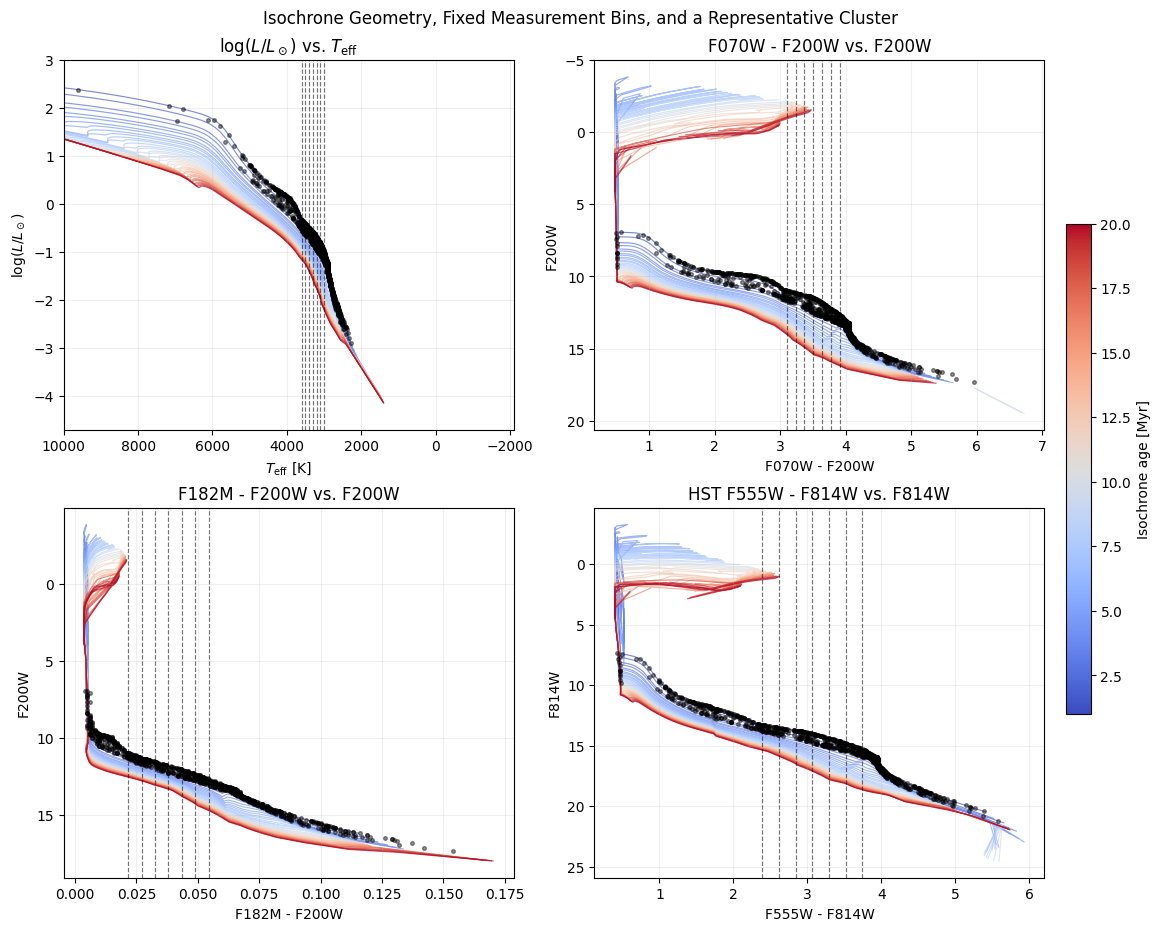

Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=2 Myr


Saved: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs/fig_representative_cluster_f182m_f200w.png


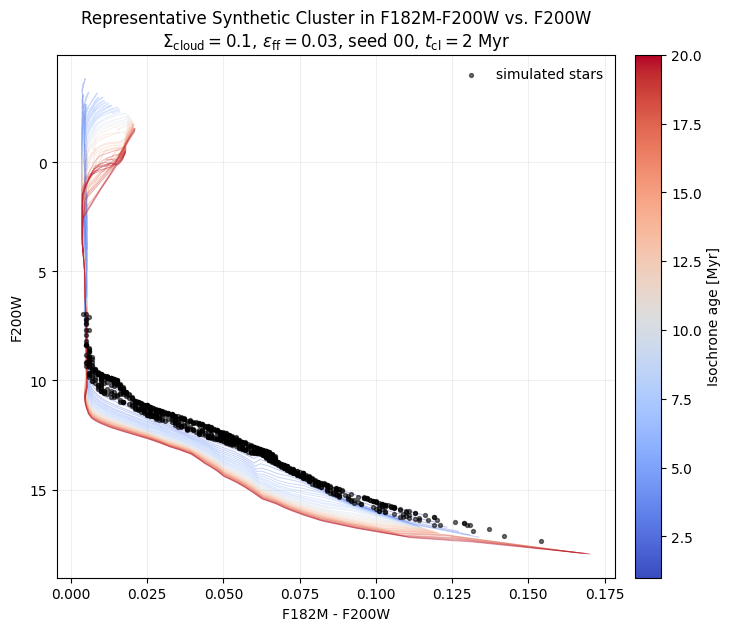

Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=1 Myr


Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=2 Myr


Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=5 Myr


Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=10 Myr


Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=15 Myr


Loading representative seed 00: Sigma=0.1, epsilon_ff=0.03, t=20 Myr


Saved: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs/fig_cluster_time_evolution_f182m_f200w.png


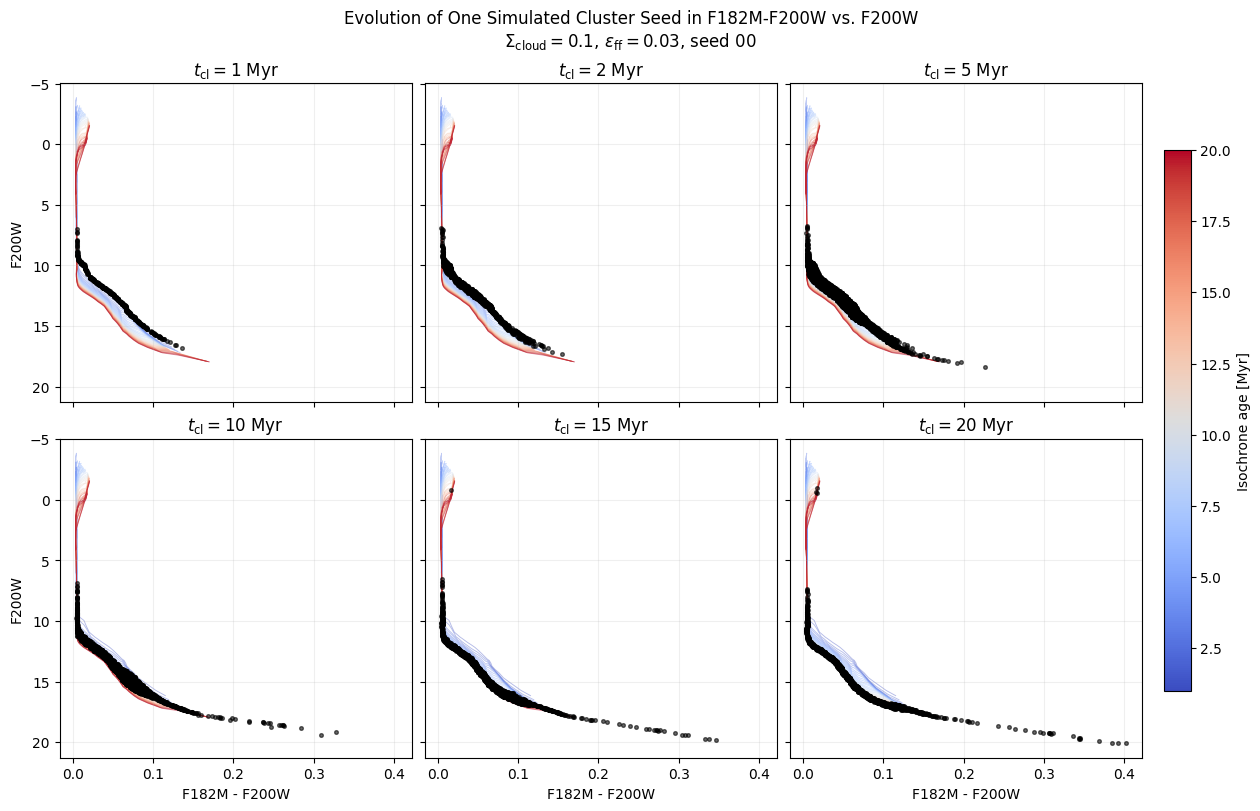

Saved: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs/fig_ensemble_age_spread_vs_time.png


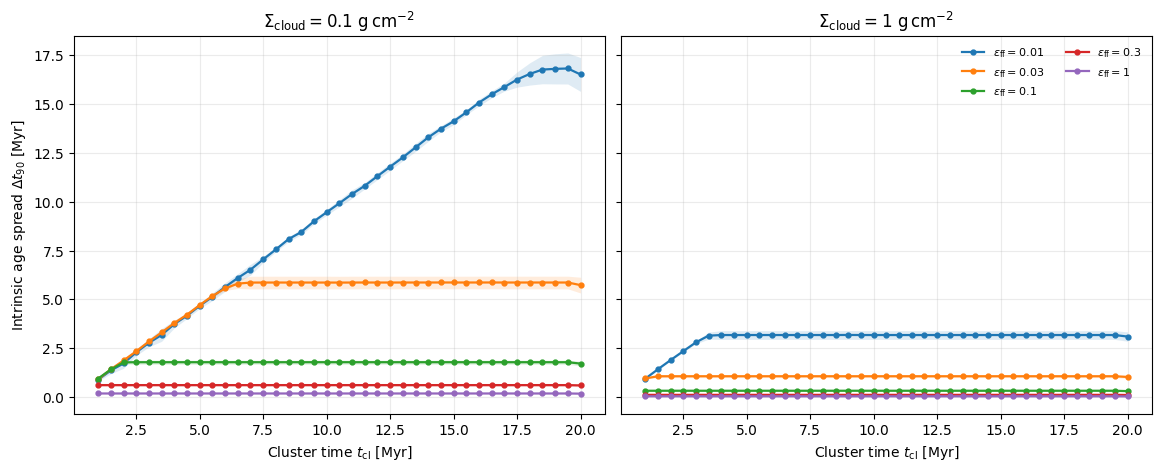

Saved: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs/fig_ensemble_spread_vs_time_all_spaces.png


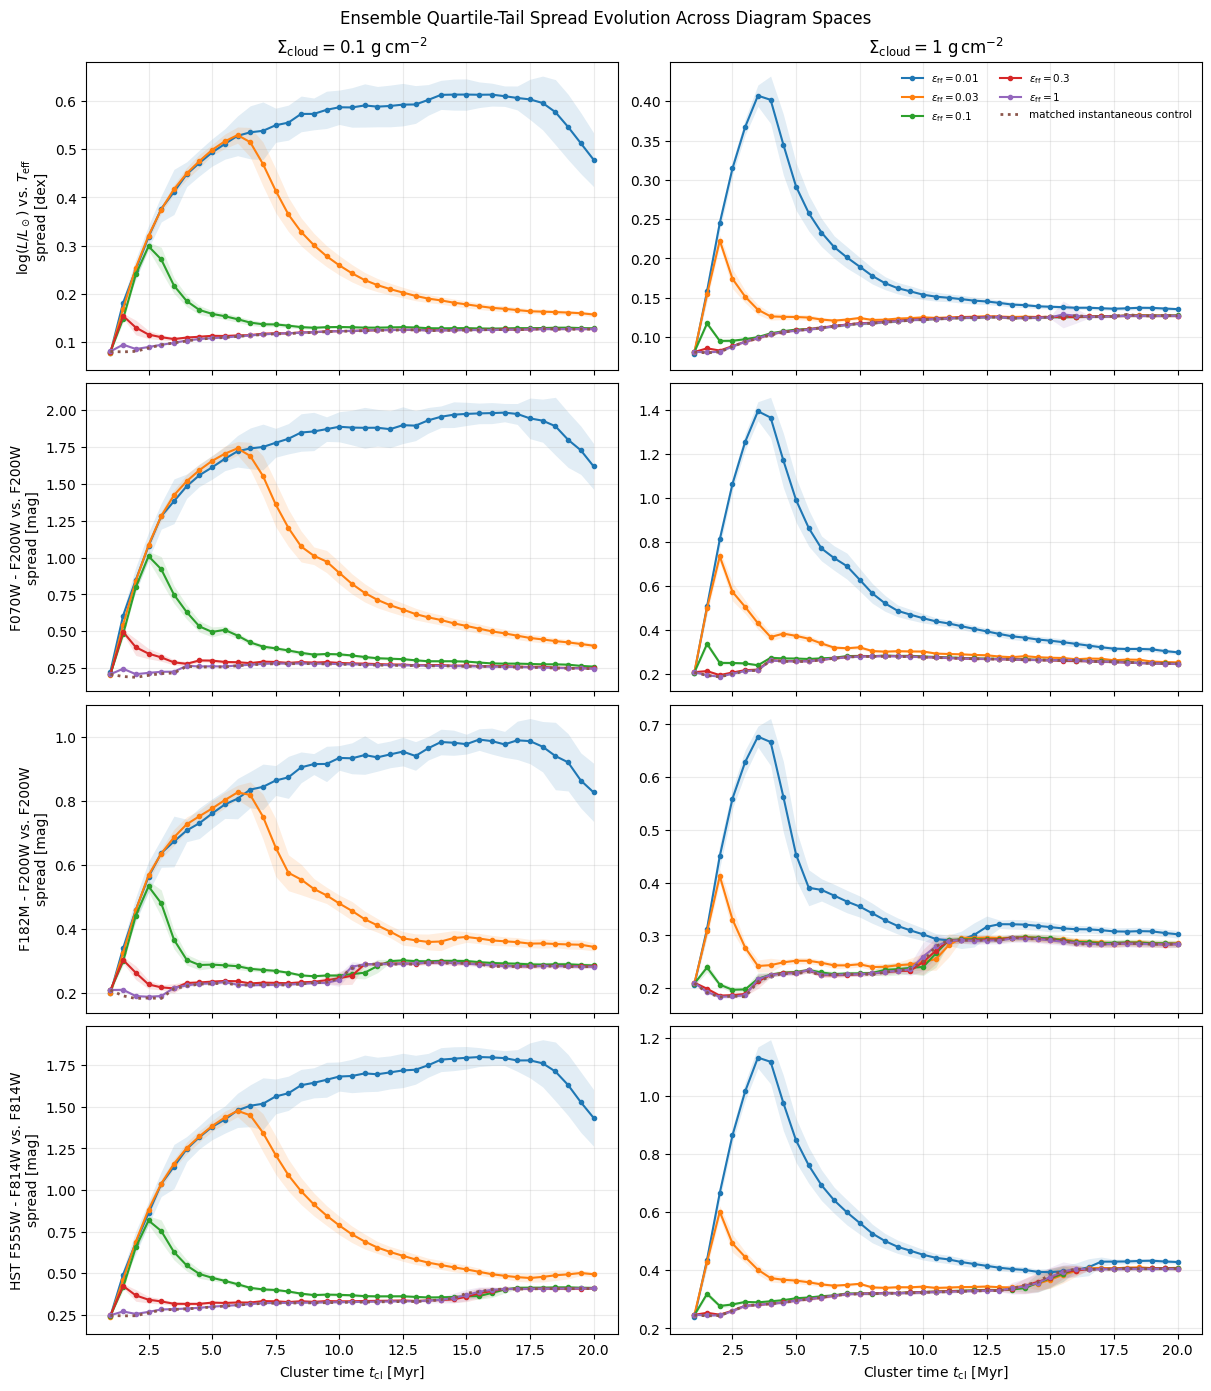

Saved: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs/fig_ensemble_spread_vs_age_spread_all_spaces.png


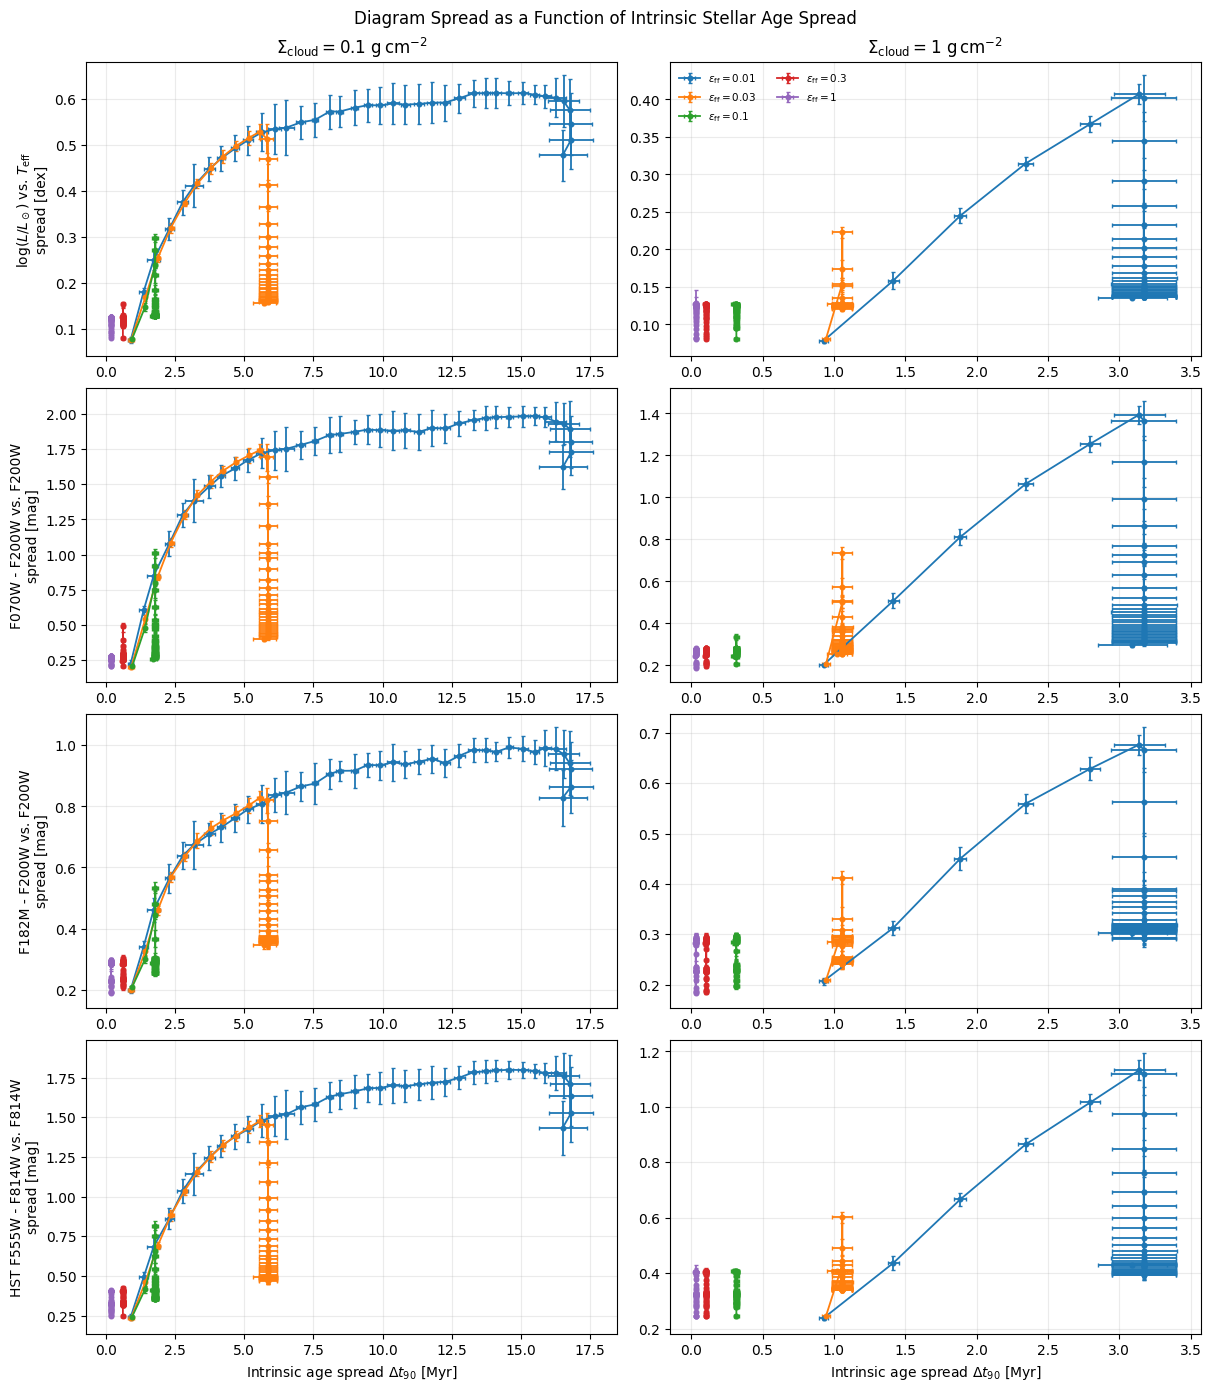

In [17]:
if GENERATE_ISOCHRONE_GEOMETRY:
    finish_figure(
        plot_analysis_space_isochrone_geometry(),
        "fig_analysis_space_isochrone_geometry.png",
    )

if GENERATE_REPRESENTATIVE_CLUSTER:
    finish_figure(
        plot_representative_cluster_f182m_f200w(),
        "fig_representative_cluster_f182m_f200w.png",
    )

if GENERATE_CLUSTER_TIME_EVOLUTION:
    finish_figure(
        plot_cluster_time_evolution_f182m_f200w(),
        "fig_cluster_time_evolution_f182m_f200w.png",
    )


if GENERATE_AGE_SPREAD_FIGURE:
    finish_figure(
        plot_ensemble_age_spread_vs_time(),
        "fig_ensemble_age_spread_vs_time.png",
    )

if GENERATE_ENSEMBLE_TIME_FIGURE:
    finish_figure(
        plot_ensemble_spread_vs_time_all_spaces(),
        "fig_ensemble_spread_vs_time_all_spaces.png",
    )

if GENERATE_ENSEMBLE_AGE_RELATION_FIGURE:
    finish_figure(
        plot_ensemble_spread_vs_age_spread_all_spaces(),
        "fig_ensemble_spread_vs_age_spread_all_spaces.png",
    )

## Summary

In [18]:
print("\n" + "=" * 80)
print("Revised paper figure generation complete")
print("Output directory:", FIGURE_OUTPUT_DIR.resolve())

print("\nGenerated/replacement figure set:")
print("  fig_analysis_space_isochrone_geometry.png")
print("  fig_representative_cluster_f182m_f200w.png")
print("  fig_cluster_time_evolution_f182m_f200w.png")
print("  fig_ensemble_age_spread_vs_time.png")
print("  fig_ensemble_spread_vs_time_all_spaces.png")
print("  fig_ensemble_spread_vs_age_spread_all_spaces.png")


Revised paper figure generation complete
Output directory: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis/paper_figure_outputs

Generated/replacement figure set:
  fig_analysis_space_isochrone_geometry.png
  fig_representative_cluster_f182m_f200w.png
  fig_cluster_time_evolution_f182m_f200w.png
  fig_ensemble_age_spread_vs_time.png
  fig_ensemble_spread_vs_time_all_spaces.png
  fig_ensemble_spread_vs_age_spread_all_spaces.png
